# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: **Borbala Balas**
* Username: **bbalas**
* Student s-number: **S6449549**
* Group (AS1, etc.): **AS3**

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

### Derivation

* With Taylor expansion
\begin{equation}
    \frac{\partial g}{\partial L} = \frac{4{\pi}^2}{T^2}
    \\
    \frac{\partial g}{\partial T} = -\frac{8{\pi}^2L}{T^3}
\end{equation}

\begin{equation}
    \Delta g = \sqrt{\frac{\partial^2 g}{\partial L^2} \left(\Delta L\right)^2 +\frac{\partial^2 g}{\partial T^2} \left(\Delta T\right)^2}
\end{equation}

In [2]:
import numpy as np

T = 2.01
dT = 0.02
L = 1
dL = 0.01
g = 4*np.pi**2*L/T**2

dg_L = 4*np.pi**2/T**2
dg_T = -8*np.pi**2*L/T**3

dg = np.sqrt(dg_L**2*dL**2+dg_T**2*dT**2)                                           # calculated dg by the formulae derived above
print(f'dg with Tylor expansion is {dg} m/s^2 \ng = {g:.2f}±{dg:.2f} m/s^2')

# With Monte-Carlo
t = np.linspace(T-dT,T+dT,2000)                             # makes 20 "measurement results" within the band
l = np.linspace(L-dL,L+dL,2000)                             # makes 2s0 "measurement results" within the band

g_MC = []
for i in range(2000):
    a = np.random.choice(t)                               # chooses one data from each group
    b = np.random.choice(l)                               # chooses one data from each group
    g_MC.append(4*np.pi**2*b/T**a)                        # calculates g for each one of them
g_MC = np.array(g_MC)

print(f"The uncertainty of g using Monte-Carlo is {np.std(g_MC)} m/s^2")  # dg ≈ the standard deviation of the results
print(f"g_Monte-Carlo = {np.mean(g_MC):.2f}±{np.std(g_MC):.2f} m/s^2")    # g ≈ the mean of the results

print(f"The two results differ by {abs(g-np.mean(g_MC)):.2f} m/s^2, the uncertainties by {abs(dg-np.std(g_MC)):.2f} m/s^2")

dg with Tylor expansion is 0.2176313753358241 m/s^2 
g = 9.77±0.22 m/s^2
The uncertainty of g using Monte-Carlo is 0.09529221153972207 m/s^2
g_Monte-Carlo = 9.71±0.10 m/s^2
The two results differ by 0.07 m/s^2, the uncertainties by 0.12 m/s^2


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
import math
def type_check(string):
    """Ensures that the user entered a number"""
    try:
        float(string)
        return True
    except ValueError:
        return False
    
a = input('Enter the coefficient of the quadratic term: ')
while not(type_check(a)):
    a = input('Please enter a number: ')
a = float(a)

b = input('Enter the coefficient of the linear term: ')
while not(type_check(b)):
    b = input('Please enter a number: ')
b = float(b)

c = input('Enter the constant term: ')
while not(type_check(c)):
    c = input('Please enter a number: ')
c = float(c)

y = input('Enter the corresponding y value: ')
while not(type_check(y)):
    y = input('Please enter a number: ')
y = float(y)

D = b**2-4*a*(c-y)

if D>0:
    x1 = (-b+math.sqrt(D))/(2*a)              # for real roots D is used
    x2 = (-b-math.sqrt(D))/(2*a)
    print(f"The two solutions for the quadratic equation ({a})*x^2+({b})*x+({c-y})=0 are {x1:.3f} and {x2:.3f}.")
    
elif D == 0:
    x1 = x2 = -b/(2*a)
    print(f"The quadratic equation ({a})*x^2+({b})*x+({c-y})=0 are has one solution, which is {x1:.3f}.")
else:
    x1 = (-b+math.sqrt(-D)*1j)/(2*a)          # for complex roots -D is used
    x2 = (-b-math.sqrt(-D)*1j)/(2*a)
    print(f"The two solutions for the quadratic equation ({a})*x^2+({b})*x+({c-y})=0 are {x1:.3f} and {x2:.3f}.")
    
y1 = a*x1**2+b*x1+c
y2 = a*x2**2+b*x2+c
print(f'Check: inserting a = {a}, b = {b}, c = {c} to ax^2+bx+c=y, we get, that y1 = {y1.real} and y2 = {y2.real}, that differ from the input y by {(y1-y).real} and {(y2-y).real} .')

Enter the coefficient of the quadratic term:  1
Enter the coefficient of the linear term:  30
Enter the constant term:  5
Enter the corresponding y value:  2


The two solutions for the quadratic equation (1.0)*x^2+(30.0)*x+(3.0)=0 are -0.100 and -29.900.
Check: inserting a = 1.0, b = 30.0, c = 5.0 to ax^2+bx+c=y, we get, that y1 = 1.9999999999999947 and y2 = 2.0, that differ from the input y by -5.329070518200751e-15 and 0.0 .


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

The integral between x = 0 and 2.5 is 1.9769788548675902
The integral between x = ±infinity is 5.013256549262001
The difference between the two results is -8.881784197001252e-16 which is approximately 0. The results match.


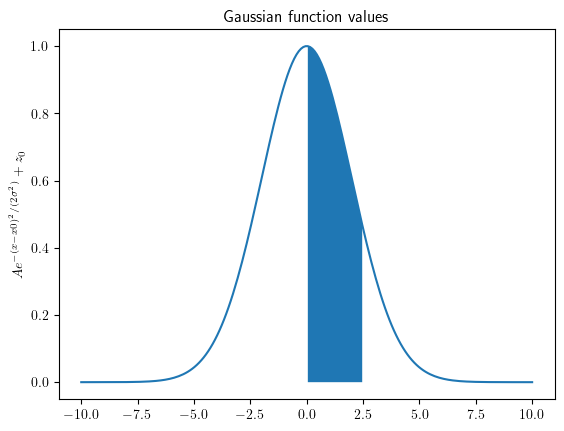

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

A = 1.0
x0 = 0.0
sig = 2.0
z0 = 0.0

x = np.linspace(-10,10,200)
y = gauss(x, A, x0, sig, z0)

x2 = x[np.where((0 <= x) & (x <= 2.5))]

plt.rc("text",usetex = True)
plt.title("Gaussian function values")
plt.ylabel("$A e^{-(x-x0)^2/(2 \sigma^2)}+z_0$")
plt.plot(x,y)
plt.fill_between(x2,gauss(x2, A, x0, sig, z0))

print("The integral between x = 0 and 2.5 is",scipy.integrate.quad(gauss,0,2.5, args=(A, x0, sig, z0,))[0])

area1 = scipy.integrate.quad(gauss,-np.inf,np.inf,args=(A, x0, sig, z0,))[0] 
print("The integral between x = ±infinity is",area1) #bounds set to +- 2000 because if set to +-np.inf the integral gives 0

area2 = A*sig*np.sqrt(2*np.pi)

print(f"The difference between the two results is {area2-area1} which is approximately 0. The results match.")

The gaussian distribution function has a form of  𝑓(𝑥) = 𝐴 * exp[−(𝑥−𝑥0)^2/(2𝜎^2)+𝑧0]


Enter the value for A:  32
Enter the value for x0:  3
Enter the value for 𝜎:  431
Enter the value for z0:  0
Enter the value for the lower bound of the function:  -78.36
Enter the value for the upper bound of the function:  21


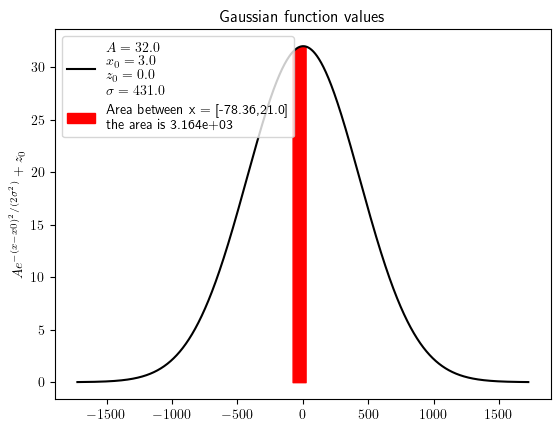

The area below the curve on the relevant domain is 3163.972498378037


In [25]:
def type_check(string):
    try:
        float(string)
        return True
    except ValueError:
        return False

def inputs(name):
    var = input(f"Enter the value for {name}: ")
    while not(type_check(var)):
        var = input('Please enter a number: ')
    return float(var)

def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

print("The gaussian distribution function has a form of  𝑓(𝑥) = 𝐴 * exp[−(𝑥−𝑥0)^2/(2𝜎^2)+𝑧0]")

A = inputs("A")
x0 = inputs("x0")

sig = inputs("𝜎")
while sig == 0.0:
    print("The standard deviation must not be 0")
    sig = inputs("𝜎")
    
z0 = inputs("z0")
a = inputs("the lower bound of the function")
b = inputs("the upper bound of the function")

if b < a:
    a,b = b,a # the AREA is always positive

bound = [-4*sig if a > -4*sig else a ,4*sig if b < 4*sig else b]            # the 4sigma bound ensures that the whole peak is shown
x1 = np.linspace(bound[0],bound[1],10000)
y1 = gauss(x1, A, x0, sig, z0)

x2 = np.linspace(a,b,10000)
y2 = gauss(x2, A, x0, sig, z0)

plt.rc("text",usetex = True)
plt.title("Gaussian function values")
plt.ylabel("$A e^{-(x-x0)^2/(2 \sigma^2)}+z_0$")
plt.plot(x1,y1, color = 'black', label = f"$A={A}$ \n$x_0={x0}$ \n$z_0={z0}$\n$\sigma={sig}$")
plt.fill_between(x2,gauss(x2, A, x0, sig, z0),color = 'red', label = f'Area between x = [{a},{b}] \nthe area is {scipy.integrate.quad(gauss,a,b, args=(A,x0,sig,z0,))[0]:.3e}')
plt.legend(loc='upper right' if x0 < sum(bound)/2 else 'upper left')

plt.show()

print(f'The area below the curve on the relevant domain is {scipy.integrate.quad(gauss,a,b, args=(A,x0,sig,z0,))[0]}')

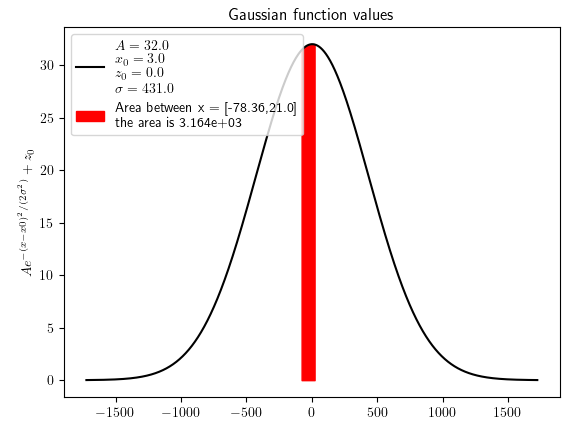
<br>
**Output for a custom function**

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [29]:
from numpy import sin, cos, exp, pi
from scipy.integrate import quad

def type_check(string):
    """Ensures that the user entered a number or pi"""
    if not(string == 'pi'):
        try:
            float(string)
            return float(string)
        except ValueError:
            return "None"        # None means, that the user has to input a new value
    else:
        return pi


def f(x,func):
    """ tries to evaluate the function """ 
    try:
        eval(func)
        return eval(func)
    except SyntaxError or NameError or ValueError:
        return "None"              # None means, that the user has to input a new function

print('IMPORTANT: use python syntax!')
fun = input("Enter a function (possible functions: sin,cos,exp or polinomials): ")

a = input("Enter the lower bound for the integration (possible constants: pi): ")
while (type(type_check(a)) != float):
   a = input('Please enter a number: ')
    
a = type_check(a)

b = input("Enter the upper bound for the integration (possible constants: pi): ")
while (type(type_check(b)) != float):
   b = input('Please enter a number: ')
b = type_check(b)

while f(a,fun) == "None":
    print(f'The function {fun} contains elements, that cannot be recognised by the program.')
    fun = input("Enter another function (possible functions: sin,cos,exp or polinomials): ")

n = 100000
domain = np.linspace(a,b,n)

if ('x' in fun) and ("None" in f(domain,fun)):                               # sees if integration is possible on the domain
    print('The function has a non-iterable part on the domain')
    fun = input("Enter another function (possible functions: sin,cos,exp or polinomials): ")


if not('x' in fun):                     # constant functions cannot be summed
    integral = f(domain,fun)*(b-a)
else:
    integral = sum(f(domain,fun))*(b-a)/n
    
print(f'The integral of the function {fun} on the given domain [{a},{b}] is {integral:.4f}')

func1 = 'x**4+exp(sin(x)+cos(x))'                      # The function provided in the description

d = np.linspace(0,pi,n)
integral = quad(f,0,pi, args = (func1,))
integral2 = sum(f(d,func1))*pi/n                        # Applies Monte-Carlo to the function

print(f'The integral of the function \'{func1}\' on the given domain [{0},pi] is {integral[0]:.4f} using scipy\'s quad() function.')
print(f'The integral of the function \'{func1}\' on the given domain [{0},pi] is {integral2:.4f} using Monte-Carlo integration.')

IMPORTANT: use python syntax!


Enter a function (possible functions: sin,cos,exp or polinomials):  x**(4/5)
Enter the lower bound for the integration (possible constants: pi):  0
Enter the upper bound for the integration (possible constants: pi):  pi


The integral of the function x**(4/5) on the given domain [0.0,3.141592653589793] is 4.3611
The integral of the function 'x**4+exp(sin(x)+cos(x))' on the given domain [0,pi] is 68.7293 using scipy's quad() function.
The integral of the function 'x**4+exp(sin(x)+cos(x))' on the given domain [0,pi] is 68.7302 using Monte-Carlo integration.


In [33]:
import sympy
from sympy.abc import x

function = "x**4+exp(sin(x)+cos(x))"
intg = sympy.integrate(function, (x, 0, pi))
print(f"The integral of the function {function} on the given domain [0,pi] is: {intg.evalf(6)} using sympy")

The integral of the function x**4+exp(sin(x)+cos(x)) on the given domain [0,pi] is: 68.7293 using sympy


In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

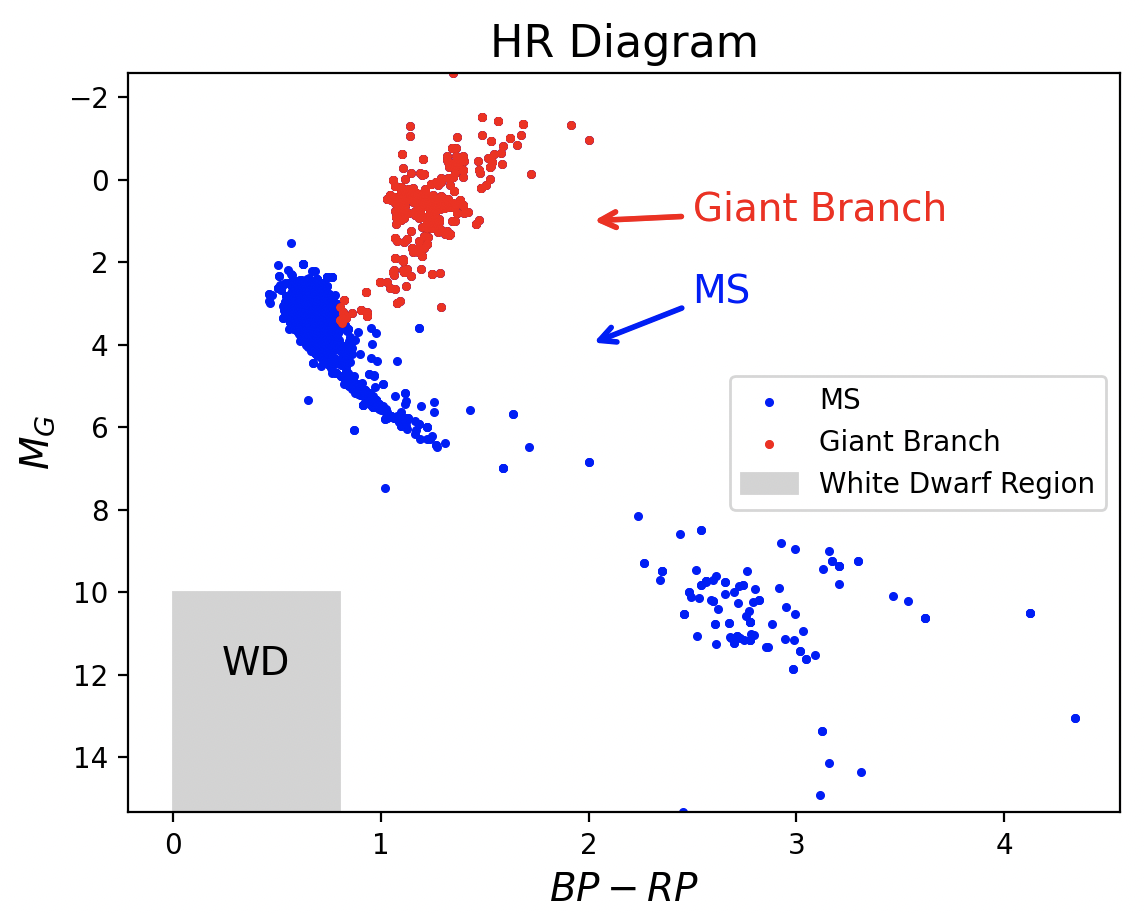

In [81]:
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names


sf = (data["STARFLAG"] == 0)                              # STARFLAG == 0
af = (data["ASPCAPFLAG"] == 0)
snr = (data["SNR"] > 10)

##################################################
err = (data["GAIAEDR3_PARALLAX"]/data["GAIAEDR3_PARALLAX_ERROR"] > 250)  # IMPORTANT after multiple trial-errors the 
                                                                         #  limit is set to 250 because 5 caused a chaotic result (attached)
                                                                         #  this way the diagram looks as the one wanted
####################################################

g = (~np.isnan(data["GAIAEDR3_PHOT_G_MEAN_MAG"]))
bp = (~np.isnan(data["GAIAEDR3_PHOT_BP_MEAN_MAG"]))
rp = (~np.isnan(data["GAIAEDR3_PHOT_RP_MEAN_MAG"]))

mask = sf & af & snr & err & g & bp & rp                  # determines for every element if all the criteria is true or not


para = data["GAIAEDR3_PARALLAX"][mask]                    # only all true criteria array elements are left
G = data["GAIAEDR3_PHOT_G_MEAN_MAG"][mask]                # only all true criteria array elements are left
BP = data["GAIAEDR3_PHOT_BP_MEAN_MAG"][mask]              # only all true criteria array elements are left
RP = data["GAIAEDR3_PHOT_RP_MEAN_MAG"][mask]              # only all true criteria array elements are left

randomly_chosen = list(np.random.randint(0,len(para),int(len(para)*0.8)))   # generates 80% of random indeces of the arrays

para = para[randomly_chosen]
G = G[randomly_chosen]
BP = BP[randomly_chosen]
RP = RP[randomly_chosen]


Mg = G + 5 + 5*np.log10(para/1000)                        # array with the correspomdimg absolute magnitudes (y-axis)
x = BP-RP                                                 # BP-RP (x-)axis

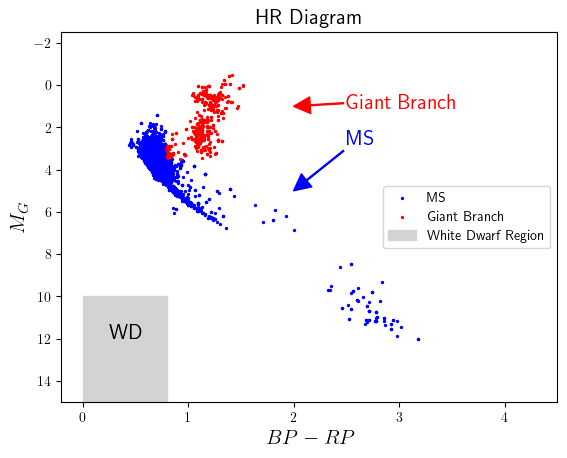

In [82]:
import matplotlib.pyplot as plt
import matplotlib.patches as ptc

Mg = np.array(Mg)
x = np.array(x)

GB = [x[(x >0.8) & (Mg < 3.5)],Mg[(x > 0.8) & (Mg < 3.5)]]
MS = [x[~((x >0.8) & (Mg < 3.5))],Mg[~((x > 0.8) & (Mg < 3.5))]]

plt.rc("text", usetex = True)
plt.title("HR Diagram", fontsize = 15)
plt.scatter(MS[0],MS[1], color = 'blue', s = 2, label = "MS")
plt.scatter(GB[0],GB[1], color = 'red', s=2, label = "Giant Branch")
plt.xlabel("$BP-RP$", fontsize = 15)
plt.ylabel("$M_G$", fontsize = 15)
plt.ylim(15,-2.5)
plt.yticks(range(-2,15,2))
plt.xlim(-0.2,4.5)
plt.xticks(range(0,5))
plt.xticks(range(0,5))


red_arrow = dict(color="red",width=0.7)
blue_arrow = dict(color="blue",width=0.7)
plt.annotate("Giant Branch",xy = (2,1), xytext=(2.5,0.75), fontsize = 15, color = 'red', arrowprops = red_arrow,verticalalignment='center_baseline')
plt.annotate("MS",xy = (2,5), xytext=(2.5,3), fontsize = 15, color = 'blue', arrowprops = blue_arrow,verticalalignment='bottom')
plt.fill_between((0,0.8),15,10,color='lightgrey',label = 'White Dwarf Region')
plt.annotate('WD',xy=(0.25, 12), color = 'black',fontsize = 15)

plt.legend(loc='center right')
plt.show()

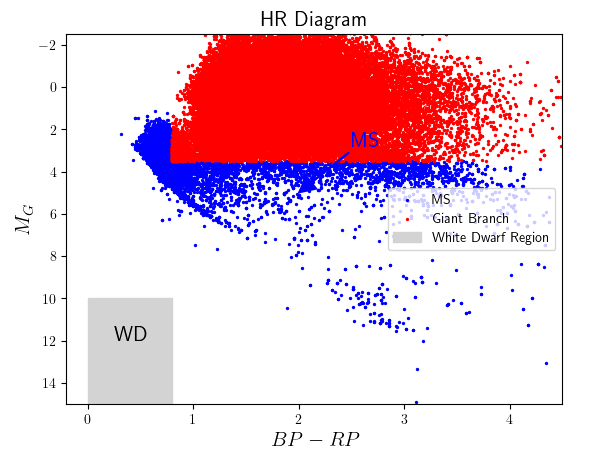
<br>
**The original HRD with the distance/error limit set to 5**

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")